# 06_Unsupervised_Model_Development_LDA

In [1]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation
import polars as pl
import joblib
from gensim.corpora import Dictionary
import duckdb
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis.lda_model
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


In [2]:
# Load the parquet file
INPUT_PATH = '../data/processed/clustered_narratives.parquet'
df_narratives = pd.read_parquet(
    INPUT_PATH,
    columns=[
        'Complaint ID',
        'processed_narrative'
    ]
)

In [3]:
df_narratives.head()

,Complaint ID,processed_narrative
0,3442136,claimed delivered package address never receiv...
1,3601853,got brink money pre paid card mail assuming un...
2,3300820,called creditor nelson cruz associate claimed ...
3,3739698,around opened credit card account online capit...
4,3285243,equifax sent credit card suggestion help impro...


In [4]:
print(len(df_narratives))

398004


## Train/Transform Vectorizer and LDA on 50k Sample

In [5]:
domain_stopwords = {
    'goldman',
    'sachs',
    'one',
    'chase',
    'well',
    'fargo',
    'capital',
    'america',
    'citibank',
    'citi',
    'jpmorgan',
    'navy',
    'federal',
    'union',
    'bank',
    'amex',
    'american',
    'express',
}

custom_stopwords = ENGLISH_STOP_WORDS.union(domain_stopwords)

In [6]:
# If re-running notebook, load the trained Vectorizer
count_vectorizer = joblib.load('../data/processed/count_vectorizer_stopwords.pkl')

In [7]:
# Transform without re-training the Vectorizer
df_lda_sample = df_narratives.sample(
    n=50_000,
    random_state=42
)

X_count = count_vectorizer.transform(
    df_lda_sample['processed_narrative']
)

print(X_count.shape)

(50000, 6107)


In [8]:
# # Train Count Vectorizer on 50k sample to save memory
# df_lda_sample = df_narratives.sample(
#     n=50_000,
#     random_state=42
# )
#
# count_vectorizer = CountVectorizer(
#     stop_words=list(custom_stopwords),
#     min_df=20,
#     max_df=0.90,
#     max_features=10_000,
# )
#
# X_count = count_vectorizer.fit_transform(
#     df_lda_sample['processed_narrative']
# )
#
# print(X_count.shape)

In [9]:
# If re-running notebook, load the trained LDA model
lda = joblib.load('../data/processed/lda_model_stopwords.pkl')

In [10]:
# Transform for LDA rather than re-train
topic_probs = lda.transform(X_count)

In [11]:
# # Train LDA on the sample
# K = 20 # Determined from parameter search
# lda = LatentDirichletAllocation(
#     n_components=K,
#     learning_method='online',
#     random_state=42,
#     n_jobs=-1,
#     batch_size=2048
# )
#
# lda.fit(X_count)

In [12]:
# Write fitted Count Vectorizer and LDA to file
joblib.dump(
    count_vectorizer,
    '../data/processed/count_vectorizer_stopwords.pkl'
)

joblib.dump(
    lda,
    '../data/processed/lda_model_stopwords.pkl'
)

['../data/processed/lda_model_stopwords.pkl']

## Examine Topic Terms

In [13]:
# Print top terms in the LDA topics
feature_names = np.array(count_vectorizer.get_feature_names_out())

for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[::-1][:8]
    top_terms = feature_names[top_indices]

    print(f'\nTopic {topic_idx}')
    print(', '.join(top_terms))


Topic 0
payment, mortgage, loan, home, escrow, year, insurance, company

Topic 1
payment, credit, card, fee, account, late, pay, time

Topic 2
document, sent, copy, letter, form, application, submitted, requested

Topic 3
account, financial, issue, matter, request, regarding, complaint, despite

Topic 4
card, charge, credit, purchase, transaction, debit, called, time

Topic 5
chime, paypal, car, rental, company, bofa, repair, vehicle

Topic 6
cash, atm, branch, money, deposit, app, withdrawal, transaction

Topic 7
told, said, called, money, time, day, asked, got

Topic 8
debt, consumer, law, security, account, state, right, notice

Topic 9
credit, report, reporting, account, information, consumer, application, bureau

Topic 10
dispute, merchant, charge, refund, credit, received, claim, provided

Topic 11
account, number, card, email, phone, address, received, information

Topic 12
account, check, fund, money, checking, deposit, closed, day

Topic 13
refund, ticket, flight, hotel, trav

In [14]:
# Add dominant topic to the sample dataframe.
# Add topic_probability which ONLY contains the probability of the dominant topic

df_lda_sample['dominant_topic'] = topic_probs.argmax(axis=1)
df_lda_sample['topic_probability'] = topic_probs.max(axis=1)

df_lda_sample['dominant_topic'].value_counts().sort_index()

dominant_topic
0     2955
1     6017
2      238
3     2332
4     3422
5      102
6      882
7     5599
8      881
9     1942
10    3236
11    3697
12    7649
13     407
14    1768
15    1249
16    1266
17    4101
18     996
19    1261
Name: count, dtype: int64

In [15]:
df_lda_sample.head()

,Complaint ID,processed_narrative,dominant_topic,topic_probability
102450,7148773,complain open bank texas day ago received regu...,11,0.229517
78236,5432970,well fargo credit card file police report repo...,17,0.913636
384187,3850335,unresolved issue citibank lasted two month sti...,12,0.255414
272901,12076787,checked account today noticed encoding error c...,12,0.466034
382568,7974309,account saving checking account closed know st...,17,0.563698


## Inspect Sample Narratives

In [16]:
# Load in cleaned narratives for the Complaint ID's in the LDA 50k sample
sample_ids = df_lda_sample['Complaint ID'].to_list()

df_readable = (
    pl.scan_parquet(INPUT_PATH)
    .filter(pl.col('Complaint ID').is_in(sample_ids))
    .select([
        'Complaint ID',
        'cleaned_consumer_narrative'
    ])
    .collect()
    .to_pandas()
)

df_lda_sample = df_lda_sample.merge(
    df_readable,
    on='Complaint ID',
    how='left'
)

In [17]:
print(df_lda_sample.columns.tolist())

['Complaint ID', 'processed_narrative', 'dominant_topic', 'topic_probability', 'cleaned_consumer_narrative']


In [18]:
# Print and inspect example narratives in each topic
for topic in sorted(df_lda_sample['dominant_topic'].unique()):
    print(f'\n===== Topic {topic} =====')

    samples = (
        df_lda_sample[df_lda_sample['dominant_topic'] == topic]
        .sample(n=3, random_state=42)
    )

    for text in samples['cleaned_consumer_narrative']:
        print('\n', text[:500])


===== Topic 0 =====

 I have had issues with my mortgage since the beginning with Selene, and I just want to say that sending my property to be auctioned off while we have a modification in the works is dual tracking and is illegal in North Carolina. I have letters from the law office explaining that my home is up for auction on REDACTED_DATE , and I had a notary sign modification papers and send them in earlier this month. With the modification approved and papers sent in the first place, my house should not be on a

 I initially applied for a mortgage assumption with PNC Bank in REDACTED REDACTED , providing all required documentation. My application was denied without a clear explanation. I reapplied in REDACTED_DATE , submitting all necessary documents again. PNC stated multiple times that they could not allocate certain documents, requiring me to resubmit them multiple times, with no clear indication of whether they were properly reviewed. On REDACTED_DATE , my application was de

In [19]:
# Generate LDA viz
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda, X_count, count_vectorizer, mds="tsne")
panel

PreparedData(topic_coordinates=                x           y  topics  cluster       Freq
topic                                                    
7      201.412323  196.732727       1        1  11.805155
12     159.999374 -244.131317       2        1  10.012272
1     -139.778091   13.148655       3        1   7.671305
11      57.073391  201.086945       4        1   7.280564
3      -24.206482   87.087807       5        1   7.096776
17    -255.651352  160.790192       6        1   6.392765
10    -280.689056   11.676964       7        1   6.259109
4      132.759369  -68.619659       8        1   5.745775
14     -43.650887  299.605835       9        1   5.448295
0      -43.100918 -899.737915      10        1   5.348888
18     112.216492   65.520416      11        1   4.174741
16     264.175751 -116.274071      12        1   4.024323
9       -6.433131 -304.390350      13        1   3.677038
8     -246.480896 -130.703796      14        1   3.448256
19      34.780396 -167.359390      15        1   3.103819
6      259.580597   44.583130      16        1   2.316107
15       2.220703  -34.071442      17        1   2.123820
2     -153.549667 -253.803223      18        1   1.898182
13    -120.269691  173.386246      19        1   1.336412
5      -97.428543 -120.688515      20        1   0.836398, topic_info=            Term           Freq          Total Category  logprob  loglift
1286      credit   67406.000000   67406.000000  Default  30.0000  30.0000
747         card   71012.000000   71012.000000  Default  29.0000  29.0000
49       account  131674.000000  131674.000000  Default  28.0000  28.0000
3860     payment   48013.000000   48013.000000  Default  27.0000  27.0000
505      balance   21373.000000   21373.000000  Default  26.0000  26.0000
...          ...            ...            ...      ...      ...      ...
5826        used     197.406259    9056.990041  Topic20  -5.2034   0.9578
3799        paid     202.552794   13086.978028  Topic20  -5.1777   0.6154
3334  mastercard     145.579170     928.753525  Topic20  -5.5080   2.9307
4911        sent     176.780457   17874.290564  Topic20  -5.3138   0.1676
1827       email     175.329733   17786.243094  Topic20  -5.3220   0.1643

[1431 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
0         3  0.012961  aadvantage
0         4  0.226815  aadvantage
0        17  0.751728  aadvantage
5         1  0.223819        able
5         2  0.172583        able
...     ...       ...         ...
6094     10  0.001912         yes
6094     12  0.021992         yes
6094     16  0.018167         yes
6094     17  0.000956         yes
6102      1  0.987711       zelle

[7657 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[8, 13, 2, 12, 4, 18, 11, 5, 15, 1, 19, 17, 10, 9, 20, 7, 16, 3, 14, 6])

## Search for Best Coherence Score

This section searches across different values of `n_topics` using the existing 50k LDA sample, `count_vectorizer`, `X_count`, and `feature_names`.

The search evaluates each model with Gensim's `c_v` coherence score. Higher coherence is better.


In [20]:
# # Helper function to extract top words from each fitted LDA topic
def get_lda_topics(
    lda_model,
    feature_names,
    n_top_words=15
):
    topics = []

    for topic in lda_model.components_:
        top_indices = topic.argsort()[::-1][:n_top_words]
        top_words = [feature_names[i] for i in top_indices]
        topics.append(top_words)

    return topics


In [21]:
# # Search for optimal K topics based on coherence scoring
#
# # feature_names = count_vectorizer.get_feature_names_out()
#
# tokenized_docs = (
#     df_lda_sample['processed_narrative']
#     .fillna('')
#     .str.split()
#     .tolist()
# )
#
# dictionary = Dictionary(tokenized_docs)
#
# lda_coherence_results = []
#
# for n_topics in [5, 10, 15, 20, 25, 30]:
#
#     lda_search = LatentDirichletAllocation(
#         n_components=n_topics,
#         learning_method='online',
#         random_state=42,
#         n_jobs=-1,
#         batch_size=2048
#     )
#
#     lda_search.fit(X_count)
#
#     topics = get_lda_topics(
#         lda_model=lda_search,
#         feature_names=feature_names,
#         n_top_words=15
#     )
#
#     coherence_model = CoherenceModel(
#         topics=topics,
#         texts=tokenized_docs,
#         dictionary=dictionary,
#         coherence='c_v'
#     )
#
#     coherence_score = coherence_model.get_coherence()
#
#     lda_coherence_results.append({
#         'n_topics': n_topics,
#         'coherence_c_v': coherence_score,
#         'perplexity': lda_search.perplexity(X_count)
#     })
#
#     print(
#         f'n_topics={n_topics}, '
#         f'coherence_c_v={coherence_score:.4f}'
#     )
#
# lda_coherence_results_df = pd.DataFrame(lda_coherence_results)
#
# lda_coherence_results_df = lda_coherence_results_df.sort_values(
#     by='coherence_c_v',
#     ascending=False
# )
#
# lda_coherence_results_df


In [22]:
# # Save the topic coherence search results
COHERENCE_RESULTS_PATH = '../data/processed/lda_topic_coherence_search.csv'
#
# lda_coherence_results_df.to_csv(
#     COHERENCE_RESULTS_PATH,
#     index=False
# )
#
# print(f'LDA coherence search results saved to: {COHERENCE_RESULTS_PATH}')


In [23]:
# Load the coherence results from file
lda_coherence_results_df = pd.read_csv(COHERENCE_RESULTS_PATH)
lda_coherence_results_df

,n_topics,coherence_c_v,perplexity
0,20,0.510835,860.526786
1,25,0.510260,853.367554
2,15,0.506082,874.856753
3,10,0.497265,893.806188
4,30,0.465062,856.881384
5,5,0.425512,951.989758


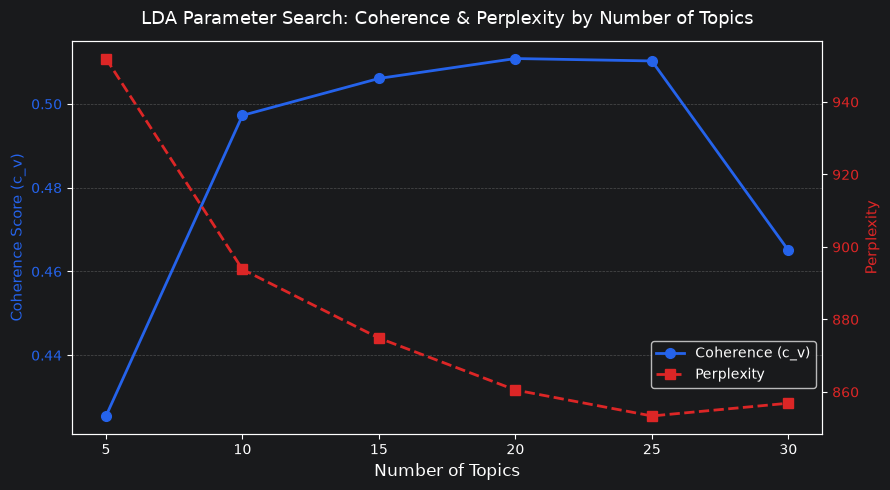

In [24]:
# Plot the scores
plot_df = lda_coherence_results_df.sort_values('n_topics')

COLOR_COH  = '#2563EB'
COLOR_PERP = '#DC2626'

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    plot_df['n_topics'],
    plot_df['coherence_c_v'],
    color=COLOR_COH,
    marker='o',
    linewidth=2,
    markersize=7,
    label='Coherence (c_v)'
)
ax1.set_xlabel('Number of Topics', fontsize=12)
ax1.set_ylabel('Coherence Score (c_v)', color=COLOR_COH, fontsize=11)
ax1.tick_params(axis='y', labelcolor=COLOR_COH)
ax1.set_xticks(plot_df['n_topics'])

ax2 = ax1.twinx()
ax2.plot(
    plot_df['n_topics'],
    plot_df['perplexity'],
    color=COLOR_PERP,
    marker='s',
    linewidth=2,
    markersize=7,
    linestyle='--',
    label='Perplexity'
)
ax2.set_ylabel('Perplexity', color=COLOR_PERP, fontsize=11)
ax2.tick_params(axis='y', labelcolor=COLOR_PERP)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='lower right',
    bbox_to_anchor=(1, 0.1),  # move left slightly
    framealpha=0.9,
    fontsize=10
)

ax1.set_title(
    'LDA Parameter Search: Coherence & Perplexity by Number of Topics',
    fontsize=13,
    pad=12
)
ax1.grid(axis='y', linestyle='--', alpha=0.35)
fig.tight_layout()
plt.show()

## Add Topic Probabilities for the 50k Sample as Features

In [25]:
# Create a dataframe with the probabilities of each topic
topic_features = pd.DataFrame(
    topic_probs,
    columns=[
        f'topic_{i}_prob'
        for i in range(topic_probs.shape[1])
    ]
)

# Horizontal concatenation - brings the topic probability columns into the original sample dataframe
df_lda_sample = pd.concat(
    [df_lda_sample.reset_index(drop=True),
     topic_features.reset_index(drop=True)],
    axis=1
)

df_lda_sample.head()

,Complaint ID,processed_narrative,dominant_topic,topic_probability,cleaned_consumer_narrative,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,...,topic_10_prob,topic_11_prob,topic_12_prob,topic_13_prob,topic_14_prob,topic_15_prob,topic_16_prob,topic_17_prob,topic_18_prob,topic_19_prob
0,7148773,complain open bank texas day ago received regu...,11,0.229517,I have a complain open No REDACTED against Ban...,0.054010,0.000588,0.228361,0.107316,0.000588,...,0.000588,0.229517,0.000588,0.000588,0.181898,0.000588,0.000588,0.000588,0.000588,0.000588
1,5432970,well fargo credit card file police report repo...,17,0.913636,Wells Fargo credit card {$3500.00} REDACTED / ...,0.004545,0.004545,0.004545,0.004545,0.004545,...,0.004545,0.004545,0.004545,0.004545,0.004545,0.004545,0.004545,0.913636,0.004545,0.004545
2,3850335,unresolved issue citibank lasted two month sti...,12,0.255414,My unresolved issues with CitiBank have now la...,0.000121,0.000121,0.000121,0.021515,0.000121,...,0.032114,0.091774,0.255414,0.000121,0.013570,0.225565,0.000121,0.094984,0.000121,0.024532
3,12076787,checked account today noticed encoding error c...,12,0.466034,I checked my account today and noticed that th...,0.000556,0.033264,0.000556,0.000556,0.000556,...,0.201136,0.000556,0.466034,0.000556,0.000556,0.000556,0.000556,0.000556,0.000556,0.031109
4,7974309,account saving checking account closed know st...,17,0.563698,My account savings and checking account was cl...,0.003571,0.003571,0.003571,0.003571,0.003571,...,0.003571,0.003571,0.372016,0.003571,0.003571,0.003571,0.003571,0.563698,0.003571,0.003571


In [26]:
# Cut down the sample dataframe to only the LDA features,
# e.g., removing narrative columns.
lda_features_sample = df_lda_sample[
    ['Complaint ID', 'dominant_topic']
    + [
        col for col in df_lda_sample.columns
        if col.startswith('topic_')
    ]
].copy()

## Apply LDA to the Remaining Records

In [27]:
# Identify remaining records outside of initial LDA sample
remaining_mask = ~df_narratives['Complaint ID'].isin(
    df_lda_sample['Complaint ID']
)

df_lda_remaining = df_narratives.loc[
    remaining_mask,
    ['Complaint ID', 'processed_narrative']
].copy()

print(f'Remaining records: {len(df_lda_remaining):,}')

Remaining records: 348,004


In [28]:
# Apply LDA to the remaining records without re-training
batch_size = 50_000
feature_batches = []

for start in range(0, len(df_lda_remaining), batch_size):
    end = min(start + batch_size, len(df_lda_remaining))

    print(f'Processing rows {start:,} to {end:,}...')

    batch = df_lda_remaining.iloc[start:end]

    X_batch = count_vectorizer.transform(
        batch['processed_narrative']
    )

    topic_probs = lda.transform(X_batch)

    topic_features = pd.DataFrame(
        topic_probs,
        columns=[
            f'topic_{i}_prob'
            for i in range(topic_probs.shape[1])
        ]
    )

    topic_features['Complaint ID'] = batch['Complaint ID'].values
    topic_features['dominant_topic'] = topic_probs.argmax(axis=1)

    feature_batches.append(topic_features)

Processing rows 0 to 50,000...
Processing rows 50,000 to 100,000...
Processing rows 100,000 to 150,000...
Processing rows 150,000 to 200,000...
Processing rows 200,000 to 250,000...
Processing rows 250,000 to 300,000...
Processing rows 300,000 to 348,004...


## Combine the Sample Dataframe with the Remaining Dataframe

In [29]:
# Stack the dataframes in the feature_batches list vertically into one dataframe.

# Feature_batches contains the dominant topics and topic probabilities for the
# remaining LDA records outside the initial 50k sample.
lda_features_remaining = pd.concat(
    feature_batches,
    ignore_index=True
)

# Specify only the LDA feature columns
cols = (
    ['Complaint ID', 'dominant_topic']
    + [
        col for col in lda_features_remaining.columns
        if col.startswith('topic_')
    ]
)

# Force both dataframes to have the same columns
lda_features_remaining = lda_features_remaining[cols]
lda_features_sample = lda_features_sample[cols]

# Concatenate the 50k LDA sample with the remaining records
lda_features_all = pd.concat(
    [lda_features_sample, lda_features_remaining],
    ignore_index=True
)

print(f'Sample rows: {len(lda_features_sample):,}')
print(f'Remaining rows: {len(lda_features_remaining):,}')
print(f'Total LDA feature rows: {len(lda_features_all):,}')

Sample rows: 50,000
Remaining rows: 348,004
Total LDA feature rows: 398,004


## Export LDA Features

In [30]:
lda_features_all.head()

,Complaint ID,dominant_topic,topic_0_prob,topic_1_prob,topic_2_prob,topic_3_prob,topic_4_prob,topic_5_prob,topic_6_prob,topic_7_prob,...,topic_10_prob,topic_11_prob,topic_12_prob,topic_13_prob,topic_14_prob,topic_15_prob,topic_16_prob,topic_17_prob,topic_18_prob,topic_19_prob
0,7148773,11,0.054010,0.000588,0.228361,0.107316,0.000588,0.000588,0.000588,0.120920,...,0.000588,0.229517,0.000588,0.000588,0.181898,0.000588,0.000588,0.000588,0.000588,0.000588
1,5432970,17,0.004545,0.004545,0.004545,0.004545,0.004545,0.004545,0.004545,0.004545,...,0.004545,0.004545,0.004545,0.004545,0.004545,0.004545,0.004545,0.913636,0.004545,0.004545
2,3850335,12,0.000121,0.000121,0.000121,0.021515,0.000121,0.000121,0.000121,0.194650,...,0.032114,0.091774,0.255414,0.000121,0.013570,0.225565,0.000121,0.094984,0.000121,0.024532
3,12076787,12,0.000556,0.033264,0.000556,0.000556,0.000556,0.000556,0.000556,0.260124,...,0.201136,0.000556,0.466034,0.000556,0.000556,0.000556,0.000556,0.000556,0.000556,0.031109
4,7974309,17,0.003571,0.003571,0.003571,0.003571,0.003571,0.003571,0.003571,0.003571,...,0.003571,0.003571,0.372016,0.003571,0.003571,0.003571,0.003571,0.563698,0.003571,0.003571


In [31]:
lda_features_all.info()

<class 'pandas.DataFrame'>
RangeIndex: 398004 entries, 0 to 398003
Data columns (total 22 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Complaint ID    398004 non-null  int64  
 1   dominant_topic  398004 non-null  int64  
 2   topic_0_prob    398004 non-null  float64
 3   topic_1_prob    398004 non-null  float64
 4   topic_2_prob    398004 non-null  float64
 5   topic_3_prob    398004 non-null  float64
 6   topic_4_prob    398004 non-null  float64
 7   topic_5_prob    398004 non-null  float64
 8   topic_6_prob    398004 non-null  float64
 9   topic_7_prob    398004 non-null  float64
 10  topic_8_prob    398004 non-null  float64
 11  topic_9_prob    398004 non-null  float64
 12  topic_10_prob   398004 non-null  float64
 13  topic_11_prob   398004 non-null  float64
 14  topic_12_prob   398004 non-null  float64
 15  topic_13_prob   398004 non-null  float64
 16  topic_14_prob   398004 non-null  float64
 17  topic_15_prob   39800

In [32]:
# Export parquet ONLY containing the LDA feature columns.
# To be joined back to the full dataframe and cluster features in the next notebook.
OUTPUT_PATH = '../data/processed/lda_features.parquet'

lda_features_all.to_parquet(
    OUTPUT_PATH,
    index=False
)

print(lda_features_all.shape)

(398004, 22)
